# Sephora Product & Review Analytics
## Step 1: Data Ingestion, Consolidation & Initial Profiling
**Author:** Data Analyst  
**BRD Reference:** BR-01, BR-02, BR-03  

---

### Notebook Objectives:
1. **Load Data:** Import `product_info.csv` and concatenate all 5 partitioned review files (`reviews_0-250.csv` through `reviews_1250-end.csv`).
2. **Schema & Integrity Checks:** Verify column data types, row counts, and join key consistency (`product_id`).
3. **Missing Value Profiling:** Generate an audit report documenting null percentages to execute BRD Section 9 cleaning rules.

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Color Palette as per BRD
SEPHORA_MAROON = "#6B1F3A"

##  Load Datasets

In [2]:
df_products = pd.read_csv("product_info.csv")

In [3]:
review_files = [
    "reviews_0-250.csv",
    "reviews_250-500.csv",
    "reviews_500-750.csv",
    "reviews_750-1250.csv",
    "reviews_1250-end.csv",]
df_reviews = pd.concat(
    [pd.read_csv(file, low_memory=False) for file in review_files],
    ignore_index=True,)

In [4]:
print(f"Products shape: {df_products.shape}")
print(f"Total Reviews shape: {df_reviews.shape}")

Products shape: (8494, 27)
Total Reviews shape: (1094411, 19)


In [5]:
df_products.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.636,11.000,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD A...",35.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.154,13.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.000,30.000
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.250,16.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.000,30.000
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.476,21.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.000,30.000
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.231,13.000,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fra...",195.000,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.000,30.000


In [6]:
df_reviews.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.000,1.000,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.000
1,1,31423088263,1,0.000,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000
2,2,5061282401,5,1.000,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000
3,3,6083038851,5,1.000,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000
4,4,47056667835,5,1.000,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.000


## Validate Join Keys Between Products and Reviews (BR-02)

In [7]:
print("Unique products in catalog:", df_products["product_id"].nunique())
print("Unique products in reviews:", df_reviews["product_id"].nunique())

Unique products in catalog: 8494
Unique products in reviews: 2351


In [8]:
matched = df_reviews["product_id"].isin(df_products["product_id"]).value_counts()
print("\nReview rows matching a catalog product:")
print(matched)


Review rows matching a catalog product:
product_id
True    1094411
Name: count, dtype: int64


All 1,094,411 reviews match the catalog ($100\%$ match)

## Check Missing Values in df_products

In [9]:
prod_nulls = df_products.isnull().sum()
prod_nulls[prod_nulls > 0]

rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
value_price_usd       8043
sale_price_usd        8224
highlights            2207
secondary_category       8
tertiary_category      990
child_max_price       5740
child_min_price       5740
dtype: int64

## Check Missing Values in df_reviews

In [10]:
rev_nulls = df_reviews.isnull().sum()
rev_nulls[rev_nulls > 0]

is_recommended    167988
helpfulness       561592
review_text         1444
review_title      310654
skin_tone         170539
eye_color         209628
skin_type         111557
hair_color        226768
dtype: int64

## Clean Product Catalog

In [11]:
# 1. Drop rows where rating or reviews is missing (~3%)
df_products_clean = df_products.dropna(subset=["rating", "reviews"]).copy()

# 2. Create binary on_sale flag (1 if sale_price_usd is present and not null, else 0)
df_products_clean["on_sale"] = df_products_clean["sale_price_usd"].notnull().astype(int)

# 3. Drop high-null pricing columns per BRD Section 9
df_products_clean.drop(columns=["value_price_usd", "sale_price_usd"], inplace=True)

# 4. Fill missing secondary/tertiary categories
df_products_clean["secondary_category"] = df_products_clean["secondary_category"].fillna("Not Specified")
df_products_clean["tertiary_category"] = df_products_clean["tertiary_category"].fillna("Not Specified")

print("Cleaned Products Shape:", df_products_clean.shape)

Cleaned Products Shape: (8216, 26)


## Clean Reviews Dataset

In [12]:
df_reviews_clean = df_reviews.copy()

In [13]:
df_reviews_clean["is_recommended"] = df_reviews_clean["is_recommended"].map({
    1.0: "Recommended",
    0.0: "Not Recommended"
}).fillna("No Opinion")

In [14]:
df_reviews_clean["helpfulness"] = df_reviews_clean["helpfulness"].fillna(0)

In [15]:
df_reviews_clean["review_text"] = df_reviews_clean["review_text"].fillna("No review text")
df_reviews_clean["review_title"] = df_reviews_clean["review_title"].fillna("No Title")

In [16]:
demo_cols = ["skin_tone", "eye_color", "skin_type", "hair_color"]
for col in demo_cols:
    df_reviews_clean[col] = df_reviews_clean[col].fillna("Not Specified")

In [17]:
print("Cleaned Reviews Shape:", df_reviews_clean.shape)
print("Remaining Nulls:", df_reviews_clean.isnull().sum().sum())

Cleaned Reviews Shape: (1094411, 19)
Remaining Nulls: 0


## Feature Engineering (BR-04, BR-05, BR-06)

In [18]:
# Parse dates and extract time dimensions (BR-05, BR-06)
df_reviews_clean["submission_time"] = pd.to_datetime(df_reviews_clean["submission_time"])
df_reviews_clean["review_year"] = df_reviews_clean["submission_time"].dt.year
df_reviews_clean["review_month"] = df_reviews_clean["submission_time"].dt.month
df_reviews_clean["review_quarter"] = df_reviews_clean["submission_time"].dt.to_period("Q").astype(str)

In [19]:
# Add price_usd to calculate revenue_proxy (BR-04)
# Map price_usd from cleaned products
price_lookup = df_products_clean.set_index("product_id")["price_usd"].to_dict()
df_reviews_clean["price_usd"] = df_reviews_clean["product_id"].map(price_lookup)

In [20]:
# Compute revenue_proxy: price_usd * total_pos_feedback_count
df_reviews_clean["revenue_proxy"] = df_reviews_clean["price_usd"] * df_reviews_clean["total_pos_feedback_count"]

In [21]:
# Fill any reviews whose product was dropped during product cleaning with 0
df_reviews_clean["revenue_proxy"] = df_reviews_clean["revenue_proxy"].fillna(0)

In [22]:
# Display sample of calculated fields
df_reviews_clean[["product_id", "submission_time", "review_year", "review_month",
                  "price_usd", "total_pos_feedback_count", "revenue_proxy"]].head()

,product_id,submission_time,review_year,review_month,price_usd,total_pos_feedback_count,revenue_proxy
0,P504322,2023-02-01,2023,2,19.000,2,38.000
1,P420652,2023-03-21,2023,3,24.000,0,0.000
2,P420652,2023-03-21,2023,3,24.000,0,0.000
3,P420652,2023-03-20,2023,3,24.000,0,0.000
4,P420652,2023-03-20,2023,3,24.000,0,0.000


## Export Cleaned Datasets

In [23]:
df_products_clean.to_csv("products_clean.csv", index=False)
print("Saved products_clean.csv successfully!")

Saved products_clean.csv successfully!


In [24]:
df_products_clean.shape

(8216, 26)

In [25]:
df_reviews_clean.to_csv("reviews_clean.csv", index=False)
print("Saved reviews_clean.csv successfully!")

Saved reviews_clean.csv successfully!


In [26]:
df_reviews_clean.shape

(1094411, 23)

## Exploratory Data Analysis & Trends

##  Monthly Revenue Proxy Trend

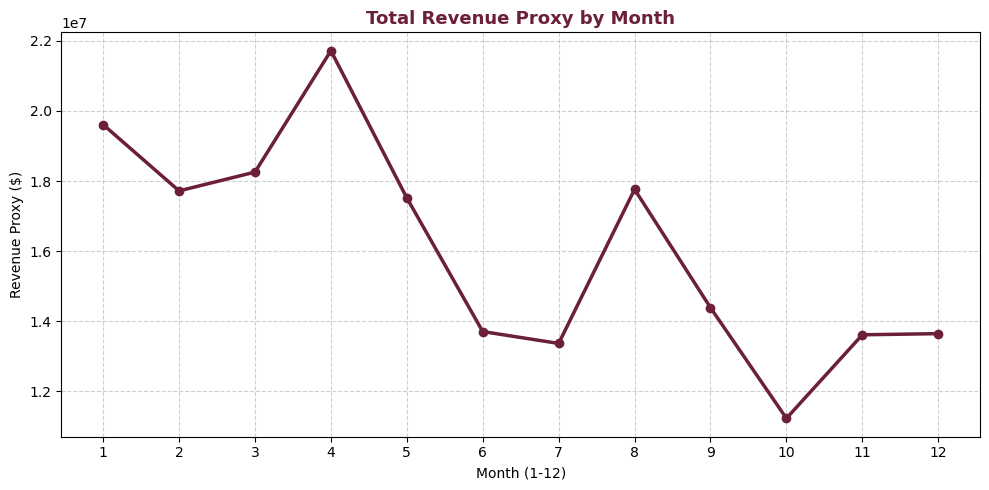

In [27]:

monthly_rev = df_reviews_clean.groupby("review_month")["revenue_proxy"].sum()

# Plot line chart
plt.figure(figsize=(10, 5))
plt.plot(monthly_rev.index, monthly_rev.values, marker="o", color="#6B1F3A", linewidth=2.5)
plt.title("Total Revenue Proxy by Month", fontsize=13, fontweight="bold", color="#6B1F3A")
plt.xlabel("Month (1-12)")
plt.ylabel("Revenue Proxy ($)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("monthly_revenue_proxy_trend.png", dpi=300, bbox_inches="tight")
plt.show()

##  Rating Distribution
Check how customer ratings (1 to 5 stars) are distributed in reviews.

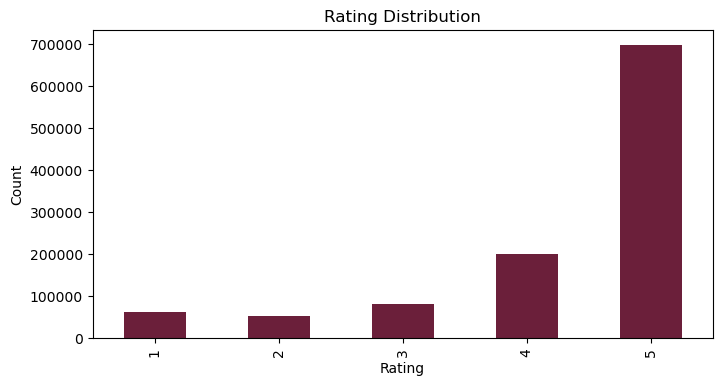

In [28]:
df_reviews_clean["rating"].value_counts().sort_index().plot(
    kind="bar",
    color="#6B1F3A",
    figsize=(8, 4),
    title="Rating Distribution"
)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.savefig("rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Top 10 Product Categories (BR-05)
Identify the primary categories with the highest number of catalog listings.

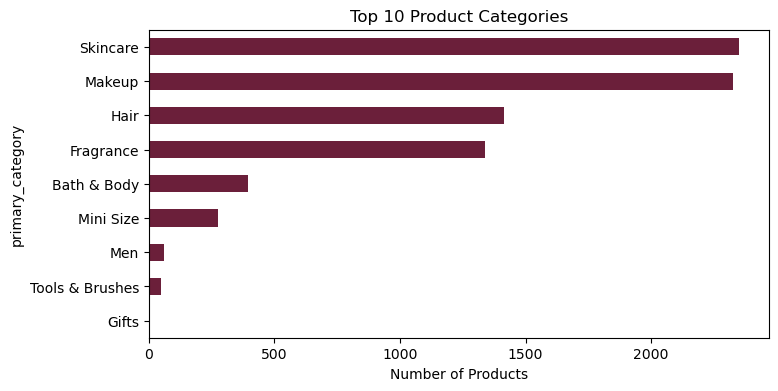

In [29]:
df_products_clean["primary_category"].value_counts().head(10).plot(
    kind="barh",
    color="#6B1F3A",
    figsize=(8, 4),
    title="Top 10 Product Categories"
).invert_yaxis()

plt.xlabel("Number of Products")
plt.savefig("top_10_product_categories.png", dpi=300, bbox_inches="tight")
plt.show()

### Recommendation Status Breakdown 
Check the share of Recommended, Not Recommended, and No Opinion reviews per BRD rules.

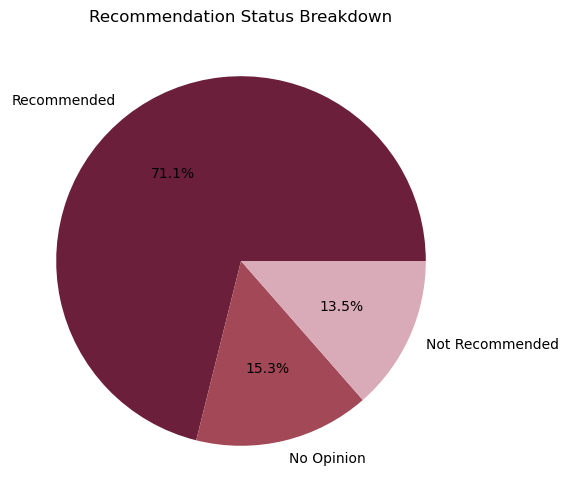

In [30]:
df_reviews_clean["is_recommended"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["#6B1F3A", "#A24857", "#D9AAB7"],
    figsize=(6, 6),
    title="Recommendation Status Breakdown"
)
plt.ylabel("")
plt.savefig("recommendation_status_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 1 Summary: Data Cleaning & EDA

**1. Data Cleaning Actions**
* **Merged Data:** Combined all 5 review files into 1,094,411 rows with 100% match on product_id.
* **Cleaned Products:** Dropped 278 rows missing ratings/reviews (~3.3%). Dropped high-null price columns and created an on_sale flag.
* **Cleaned Reviews:** Filled missing recommendation values with "No Opinion", missing helpfulness with 0, and missing demographics with "Not Specified".
* **Feature Engineering:** Calculated revenue_proxy (price * positive feedback) and extracted month, year, and quarter.
* **Exported Files:** Saved products_clean.csv (8,216 rows) and reviews_clean.csv (1,094,411 rows).

---

**2. Key Insights**
* **Seasonal Demand:** Revenue proxy peaks in April (21.8M USD), with smaller spikes in January (19.6M USD) and August (17.8M USD). The lowest point is October (11.3M USD).
* **Customer Sentiment:** Ratings are heavily positive; 71.1% of reviews recommend products and 5-star reviews dominate.
* **Top Categories:** Skincare and Makeup are the largest categories by catalog count (>2,300 products each).

---

**Next Step:** Proceed to Step 2: SQL Business Queries.